C:/Users/wzimm/Desktop/LC-MARE/data_test_1/1B843C2E_20260607/09/1B843C2E_20260607_093500.bin
C:/Users/wzimm/Desktop/LC-MARE/data_test_1/1B482F2E_20260607/11/1B482F2E_20260607_111000.bin
C:/Users/wzimm/Desktop/LC-MARE/data_test_1/13881121_20260607/11/13881121_20260607_113400.bin
C:/Users/wzimm/Desktop/LC-MARE/data_test_1/1B9A492E_20260607/11/1B9A492E_20260607_114200.bin
C:/Users/wzimm/Desktop/LC-MARE/data_test_1/1B95322E_20260607/12/1B95322E_20260607_120600.bin
C:/Users/wzimm/Desktop/LC-MARE/data_test_1/1B30112D_20260607/12/1B30112D_20260607_122300.bin
C:/Users/wzimm/Desktop/LC-MARE/data_test_1/1B544A2E_20260607/14/1B544A2E_20260607_143300.bin
C:/Users/wzimm/Desktop/LC-MARE/data_test_1/1B834E2C_20260607/14/1B834E2C_20260607_141200.bin
C:/Users/wzimm/Desktop/LC-MARE/data_test_1/1B144B2E_20260607/14/1B144B2E_20260607_144300.bin
C:/Users/wzimm/Desktop/LC-MARE/data_test_1/1B37362E_20260607/14/1B37362E_20260607_145000.bin
C:/Users/wzimm/Desktop/LC-MARE/data_test_1/13753321_20260607/14/137533

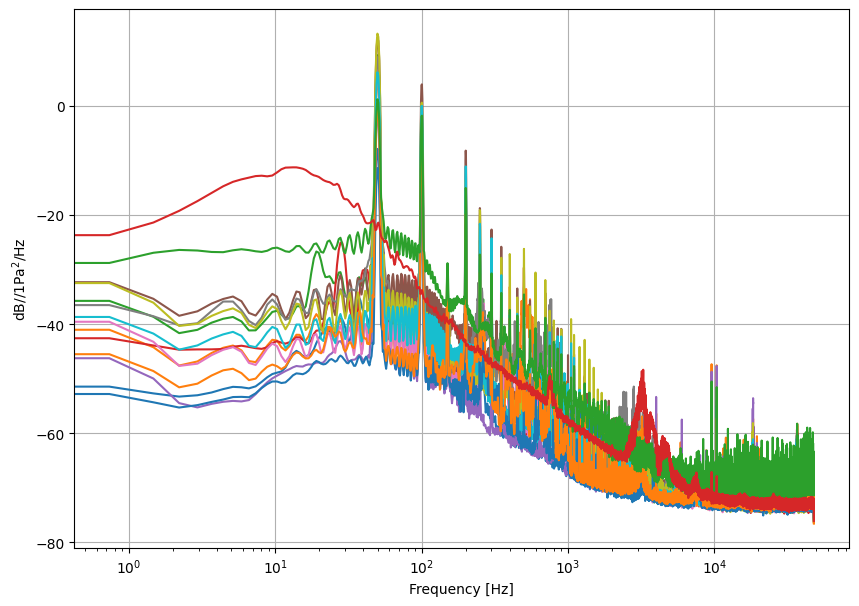

In [14]:
root="C:/Users/wzimm/Desktop/LC-MARE/data_test_1/"
files=["1B843C2E_20260607/09/1B843C2E_20260607_093500.bin",
       "1B482F2E_20260607/11/1B482F2E_20260607_111000.bin",
       "13881121_20260607/11/13881121_20260607_113400.bin",
       "1B9A492E_20260607/11/1B9A492E_20260607_114200.bin",
       "1B95322E_20260607/12/1B95322E_20260607_120600.bin",
       "1B30112D_20260607/12/1B30112D_20260607_122300.bin",
       "1B544A2E_20260607/14/1B544A2E_20260607_143300.bin",
       "1B834E2C_20260607/14/1B834E2C_20260607_141200.bin",
       "1B144B2E_20260607/14/1B144B2E_20260607_144300.bin",
       "1B37362E_20260607/14/1B37362E_20260607_145000.bin",
       "13753321_20260607/14/13753321_20260607_145700.bin",
       "1B26222E_20260607/15/1B26222E_20260607_151000.bin",
       "1B525C2C_20260607/15/1B525C2C_20260607_151700.bin",
       "1B6C4B2E_20260607/15/1B6C4B2E_20260607_153400.bin"]

from microPAM import load_microPAM, dB
import matplotlib.pyplot as plt
from scipy.signal import welch

plt.figure(figsize=(10,7))
for file in files:
    fname=root+file
    print(fname)
    fs,data,it = load_microPAM(fname)
    # calibrate data (LC-Mare)
    sens=-86 # dB//1V/Pa         # assume 1 Pa generates 50 E-6 V (10**(-86/20)) (sensitivity -206 dB//1V/uPa)
    data /= 10**(sens/20)

    nw=64*1024
    fw,qw=welch(data[:,0],fs=fs,window='hann',nperseg=nw,noverlap=nw//2,nfft=nw*2,scaling='density')

    plt.plot(fw,dB(qw))

plt.ylabel('dB//1Pa$^2$/Hz')
plt.xlabel('Frequency [Hz]')
plt.grid(True)
plt.xscale('log')
